#HW: Sentece contrastive learning

 This homework is about learning sentence representation and contrastive learning.


 From previous homework, we used to build token/sequence classification task and learn it through only supervised method. In real-world scenario, **human annotation** requires a lot of cost and effort to do. Some annotation tasks might require domain experts such as medical domain, legal domain, etc. However, there are some **unsupervised** methods which are no need any annotations.


 **Contrastive learning** is the popular one of unsupervised learning approach. It will learn the representation via similar and dissimilar examples.

 For this homework, we will focus on **SimCSE** framework which is one of contrastive learning techniques. For SimCSE, it will learn sentence embedding by comparing between different views of the same sentence.

 In this homework you will perform three main tasks.

1.   Train a sentiment classification model using a pretrained model. This model uses freeze weights. That is it treats the pretrained model as a fixed feature extractor.
2.   Train a sentiment classification model using a pretrained model. This model also performs weight updates on the base model's weights.
3.   Perform SimCSE and use the sentence embedding to perform linear classification.




## Install and import libraries

Install the `datasets` library under Huggingface and `Pytorch lightning` framework.

In [143]:
import torch
from torch import nn
import torch.nn.functional as F
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoModel
)
from datasets import load_dataset
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer
from torch.utils.data import DataLoader
from torchmetrics import Accuracy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from pytorch_lightning.loggers import TensorBoardLogger

## Setup

The dataset we use for this homework is **Wisesight-Sentiment** ([huggingface](https://huggingface.co/datasets/pythainlp/wisesight_sentiment?row=3), [github](https://github.com/PyThaiNLP/wisesight-sentiment)) dataset. It is a Thai social media dataset which are labeled as **4 classes** e.g. positive, negative, neutral, and question. Furthermore, It contains both Thai, English, Emoji, and etc. That is why we choose the distilled version of multilingual BERT (mBERT) [DistilledBERT paper](https://arxiv.org/abs/1910.01108) to be a base model.

In [144]:
model_name = 'distilbert-base-multilingual-cased'
dataset = load_dataset('pythainlp/wisesight_sentiment')

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name) # Or a Thai-specific tokenizer if available

## Loading Dataset and DataLoader

### Preprocessing step

In [145]:
# Preprocessing function
def preprocess_function(examples):
    return tokenizer(examples['texts'], padding='max_length', truncation=True)

# Apply preprocessing
encoded_dataset = dataset.map(preprocess_function, batched=True)

# Change `category` key to `labels`
encoded_dataset = encoded_dataset.map(lambda examples: {'labels': [label for label in examples['category']]}, batched=True)


### Define Dataset class

In [146]:
# Create PyTorch Dataset
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val) for key, val in self.encodings[idx].items()
            if key in ['input_ids', 'attention_mask']
        }
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


### Declare Dataset and DataLoader

In [147]:
# Create Dataset object from DataFrame
train_dataset = SentimentDataset(encoded_dataset['train'], encoded_dataset['train']['labels'])
val_dataset = SentimentDataset(encoded_dataset['validation'], encoded_dataset['validation']['labels'])
test_dataset = SentimentDataset(encoded_dataset['test'], encoded_dataset['test']['labels'])

# Create dataloaders
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=0, pin_memory=True)

### Visualize dataset class distribution

Class distribution in Train Set:
Class 0: Count = 3866, Percentage = 17.87%
Class 1: Count = 11795, Percentage = 54.54%
Class 2: Count = 5491, Percentage = 25.39%
Class 3: Count = 476, Percentage = 2.20%

Class distribution in Validation Set:
Class 0: Count = 434, Percentage = 18.05%
Class 1: Count = 1291, Percentage = 53.70%
Class 2: Count = 637, Percentage = 26.50%
Class 3: Count = 42, Percentage = 1.75%

Class distribution in Test Set:
Class 0: Count = 478, Percentage = 17.90%
Class 1: Count = 1453, Percentage = 54.40%
Class 2: Count = 683, Percentage = 25.57%
Class 3: Count = 57, Percentage = 2.13%



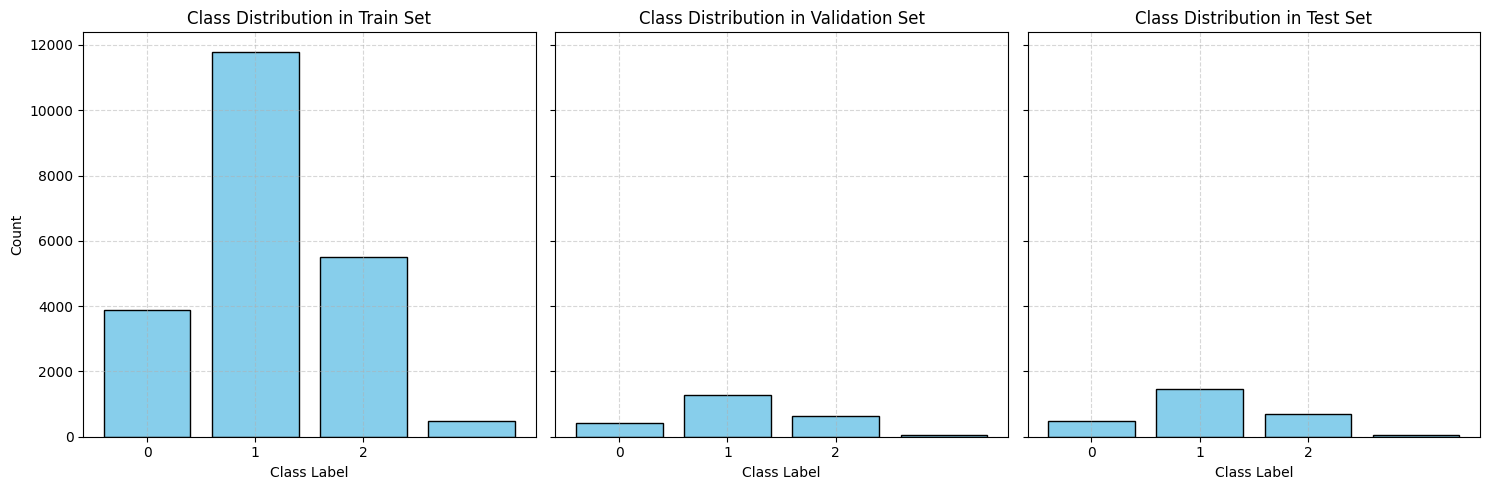

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

train_labels = encoded_dataset['train']['labels']
val_labels = encoded_dataset['validation']['labels']
test_labels = encoded_dataset['test']['labels']

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

splits = ['Train', 'Validation', 'Test']
label_data = [train_labels, val_labels, test_labels]

for ax, split, labels in zip(axs, splits, label_data):
    counts = pd.Series(labels).value_counts().sort_index()
    
    total_count = len(labels)
    percentages = (counts / total_count) * 100
    
    print(f"Class distribution in {split} Set:")
    for label, count, percentage in zip(counts.index, counts.values, percentages.values):
        print(f"Class {label}: Count = {count}, Percentage = {percentage:.2f}%")
    print()  
    
    ax.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
    ax.set_title(f"Class Distribution in {split} Set")
    ax.set_xlabel("Class Label")
    ax.set_xticks([0, 1, 2])  
    ax.grid(True, linestyle='--', alpha=0.5)

axs[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


All data set has 4 classes(positive, negative, neutral, question) and split into 3 data set(Training, Validation, Test) that has closely percent distribution for all split set.

- Positive class: ~ 18 %
- Negative class: ~ 54 %
- Neutral class: ~ 26 %
- Question class: ~ 2 %

that are highly imbalance class distribution, class 3 making only ~2% of the data across all split, so, this dataset may cause of high `false negative` for class 3. In this project we focus on `Supervise learning` and `Self-supervise learning` without talk in preprocessing(balancing, data augmentation, etc.).

## Define base model classes

Here we define model classes which will be used in the next sections.

### Base Model class

`BaseModel` is a parent class for building other models e.g.
- `Pretrained LM with a linear classifier`
- `Fine-tuned LM with a linear classifier`
- `Contrastive learning based (SimCSE) LM with a linear classifier`

In [149]:
class BaseModel(LightningModule):
    def __init__(
          self,
          model_name: str = 'distilbert-base-multilingual-cased',
          learning_rate: float = 2e-5
    ):
        super().__init__()
        self.save_hyperparameters()

        self.encoder = AutoModel.from_pretrained(model_name)
        self.learning_rate = learning_rate

    def get_embeddings(self, input_ids, attention_mask):
        
        # TODO 1: get CLS(Classification" token) token embedding to represent as a sentence embedding
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # output size = (batch size, sequence length, hidden size)
            # Sequence length
                # index[0] for [CLS] -> Special token at the beginning
                # index[-1] for [SEP] -> Special end-of-sentence token
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # ตำแหน่งที่ 0 = CLS token
        return cls_embeddings

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate)
        return optimizer

    def forward(self, input_ids, attention_mask):
        return self.get_embeddings(input_ids, attention_mask)

### LMWithLinearClassifier class

`LMWithLinearClassifier` class is designed to update both LM's parameters in the supervised approach and a linear layer's parameters.

`LMWithLinearClassfier` consists of
1. `ckpt_path` (checkpoint path) refers to the best checkpoint after training SimCSE method. We will load the encoder's weights from the checkpoint into the local encoder. This parameter will be in the section of training a linear classifier after SimCSE training part.
2. `freeze_weights` function is to convert the training status of encoder's weights to non-trainable. This function will be used in the linear classifier training part under both `Pretrained LM with a linear classifier` and `SimCSE with a linear classifier`.
3. `freeze_encoder_weights` is defined to choose whether freeze or unfreeze encoder's weights.

In [155]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
class LMWithLinearClassfier(BaseModel):
    def __init__(
          self,
          model_name: str = 'distilbert-base-multilingual-cased',
          ckpt_path: str = None,
          learning_rate: float = 2e-5,
          freeze_encoder_weights: bool = False
    ):
        super().__init__(
            model_name,
            learning_rate
        )
        self.save_hyperparameters()

        if ckpt_path is not None:
            # TODO 2: load encoder's weights from Pytorch Lightning's checkpoint
            # checkpoint = LMWithLinearClassfier.load_from_checkpoint(ckpt_path)
            checkpoint = torch.load(ckpt_path, map_location='cpu')

            # ดึง state_dict ที่เก็บพารามิเตอร์ของโมเดล
            encoder_state_dict = {
                k.replace("encoder.", ""): v
                for k, v in checkpoint['state_dict'].items()
                if k.startswith("encoder.")
            }

            # โหลด weights เฉพาะ encoder เข้าไปในโมเดลปัจจุบัน
            self.encoder.load_state_dict(encoder_state_dict)

        # TODO 3: define a linear classifier which will output the 4 classes
        self.classifier = torch.nn.Linear(self.encoder.config.hidden_size, 4)

        if freeze_encoder_weights:
          self.freeze_weights(self.encoder)  # Freeze model

        self.accuracy = Accuracy(task='multiclass', num_classes=4)
        self.all_preds = []
        self.all_labels = []

    # TODO 4: implement `freeze_weights` function which will set requires_grad
    # in the model.parameters() so that no gradient update will be done on the
    # base model. Only the linear_layer will be updated. (Hint: use .requires_grad in model.parameters())
    def freeze_weights(self, model):
        for param in model.parameters():
            param.requires_grad = False

    # TODO 5: get logits from the classifier
    def forward(self, input_ids, attention_mask):
        # ดึง sentence embedding จาก encoder (ใช้ get_embeddings ที่สืบทอดมาจาก BaseModel)
        embeddings = self.get_embeddings(input_ids, attention_mask)

        # ส่ง embedding ผ่าน linear classifier เพื่อได้ logits
        logits =self.classifier(embeddings)
        return logits

    # TODO 6.1: implement cross entropy loss for text classification
    # and log loss and acc
    def training_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        # ส่งข้อมูลผ่านโมเดล เพื่อให้ได้ logits
        logits = self(input_ids, attention_mask)

        # คำนวณ cross entropy loss
        loss = torch.nn.functional.cross_entropy(logits, labels)
        # คำนวณ accuracy
        acc = self.accuracy(logits, labels)

        # log ค่าต่าง ๆ สำหรับดูผลระหว่าง train
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=True, on_epoch=True, prog_bar=True)

        return loss

    # TODO 6.2: implement same as `training_step`
    def validation_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        logits = self(input_ids, attention_mask)
        loss = torch.nn.functional.cross_entropy(logits, labels)
        acc = self.accuracy(logits, labels)

        # log ค่าต่าง ๆ สำหรับดูผลระหว่าง train
        self.log("val_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_step=True, on_epoch=True, prog_bar=True)

    # TODO 6.3: implement same as `training_step`
    def test_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        logits = self(input_ids, attention_mask)
        loss = torch.nn.functional.cross_entropy(logits, labels)
        acc = self.accuracy(logits, labels)

        # Save predictions and labels for confusion matrix
        preds = torch.argmax(logits, dim=1)
        self.all_preds.append(preds.cpu())
        self.all_labels.append(labels.cpu())

        self.log("test_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log("test_acc", acc, on_step=True, on_epoch=True, prog_bar=True)

    def on_test_epoch_end(self):
        # Concatenate all predictions and labels
        preds = torch.cat(self.all_preds)
        labels = torch.cat(self.all_labels)

        # Compute confusion matrix
        cm = confusion_matrix(labels, preds)

        # Plot confusion matrix using seaborn
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("Confusion Matrix (Test Set)")
        plt.show()

        # Reset accumulators
        self.all_preds = []
        self.all_labels = []


## 1) Pretrained LM with a linear classifier

To benchmark models, we need to have some baselines to compare how good the models' perfomance are.


The simplest baseline to measure the contrastive learning-based method is the pretrained LM which just fine-tunes only the last linear classifier head to predict sentiments (positive/negative/neutral/questions).

### Define model

In [ ]:
pretrained_lm_w_linear_model = LMWithLinearClassfier(
    model_name,
    ckpt_path=None,
    freeze_encoder_weights=True     # Freeze weight
)

### Train a linear classifier

In [157]:
# Create a ModelCheckpoint callback (recommended way):
pretrained_lm_w_linear_checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_acc",  # Metric to monitor
    mode="max",  # "min" for loss, "max" for accuracy
    save_top_k=1,  # Save only the best model(s)
    save_weights_only=True, # Saves only weights, not the entire model
    dirpath="./checkpoints/", # Path where the checkpoints will be saved
    filename="best_pretrained_w_linear_model-{epoch}-{val_acc:.2f}", # Customized name for the checkpoint
    verbose=True,
)

In [158]:
logger = TensorBoardLogger("lightning_logs", name="Linear_model")
# Initialize trainer
pretrained_lm_w_linear_trainer = Trainer(
    logger=logger,
    max_epochs=3,
    accelerator='auto',
    callbacks=[pretrained_lm_w_linear_checkpoint_callback], # Add the ModelCheckpoint callback
    gradient_clip_val=1.0,
    precision=16, # Mixed precision training
    devices=1,
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [162]:
# Train the model
pretrained_lm_w_linear_trainer.fit(pretrained_lm_w_linear_model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | encoder    | DistilBertModel    | 134 M  | eval 
1 | classifier | Linear             | 3.1 K  | train
2 | accuracy   | MulticlassAccuracy | 0      | train
----------------------------------------------------------
3.1 K     Trainable params
134 M     Non-trainable params
134 M     Total params
538.949   Total estimated model params size (MB)
2         Modules in train mode
92        Modules in eval mode


Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 74.63it/s]

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Epoch 1: 100%|██████████| 676/676 [00:39<00:00, 17.07it/s, v_num=7, train_loss_step=0.923, train_acc_step=0.571, val_loss_step=0.779, val_acc_step=0.500, val_loss_epoch=1.040, val_acc_epoch=0.537, train_loss_epoch=1.050, train_acc_epoch=0.545]

Epoch 1, global step 1352: 'val_acc' was not in top 1


Epoch 2: 100%|██████████| 676/676 [00:39<00:00, 17.14it/s, v_num=7, train_loss_step=1.170, train_acc_step=0.500, val_loss_step=0.767, val_acc_step=0.500, val_loss_epoch=1.030, val_acc_epoch=0.537, train_loss_epoch=1.030, train_acc_epoch=0.545]

Epoch 2, global step 2028: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 676/676 [00:39<00:00, 17.14it/s, v_num=7, train_loss_step=1.170, train_acc_step=0.500, val_loss_step=0.767, val_acc_step=0.500, val_loss_epoch=1.030, val_acc_epoch=0.537, train_loss_epoch=1.030, train_acc_epoch=0.545]


### Evaluate

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 18.33it/s]

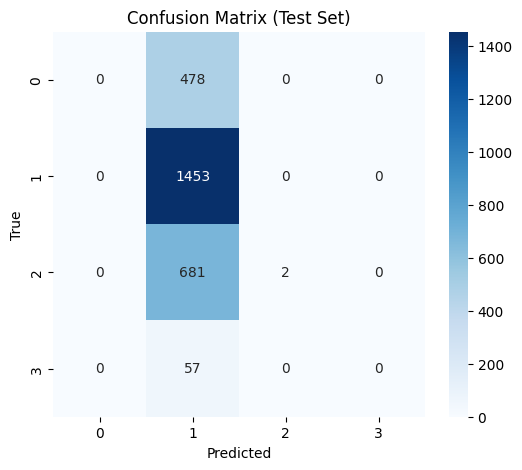

Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 18.08it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │    0.5447397828102112     │
│      test_loss_epoch      │    1.0277695655822754     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 1.0277695655822754, 'test_acc_epoch': 0.5447397828102112}]

In [163]:
pretrained_lm_w_linear_result = pretrained_lm_w_linear_trainer.test(pretrained_lm_w_linear_model, test_loader)
pretrained_lm_w_linear_result

## 2) Fine-tuned LM

This is the same as part 1, but you will also gradient update on the base model weights.

### Define model

In [164]:
#TODO 7: This is the same as part 1, but you will also gradient update on the base model weights.
finetuned_lm_w_linear_model = LMWithLinearClassfier(
    model_name,
    ckpt_path=None,
    freeze_encoder_weights=False
)

### Train both LM and a linear classifier

In [166]:

# Create a ModelCheckpoint callback (recommended way):
finetuned_lm_w_linear_checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_acc",  # Metric to monitor
    mode="max",  # "min" for loss, "max" for accuracy
    save_top_k=1,  # Save only the best model(s)
    save_weights_only=True, # Saves only weights, not the entire model
    dirpath="./checkpoints/", # Path where the checkpoints will be saved
    filename="best_finetuned_w_linear_model-{epoch}-{val_acc:.2f}", # Customized name for the checkpoint
    verbose=True,
)

logger = TensorBoardLogger("lightning_logs", name="fine_tune_LM")

# Initialize trainer
finetuned_lm_w_linear_trainer = Trainer(
    logger=logger,
    max_epochs=3,
    accelerator='auto',
    callbacks=[finetuned_lm_w_linear_checkpoint_callback], # Add the ModelCheckpoint callback
    gradient_clip_val=1.0,
    precision=16, # Mixed precision training
    devices=1,
)

import torch.multiprocessing
torch.multiprocessing.set_start_method('spawn', force=True)
# Train the model
finetuned_lm_w_linear_trainer.fit(finetuned_lm_w_linear_model, train_loader, val_loader)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | encoder    | DistilBertModel    | 134 M  | eval 
1 | classifier | Linear             | 3.1 K  | train
2 | accuracy   | MulticlassAccuracy | 0      | train
----------------------------------------------------------
134 M     Trainable params
0         Non-trainable params
134 M     Total params
538.949   Total estimated model params size (MB)
2         Modules in train mode
92        Modules in eval mode


Epoch 0: 100%|██████████| 676/676 [02:20<00:00,  4.81it/s, v_num=1, train_loss_step=0.854, train_acc_step=0.714, val_loss_step=0.400, val_acc_step=1.000, val_loss_epoch=0.728, val_acc_epoch=0.680, train_loss_epoch=0.750, train_acc_epoch=0.695]

Epoch 0, global step 676: 'val_acc' reached 0.68012 (best 0.68012), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\best_finetuned_w_linear_model-epoch=0-val_acc=0.68.ckpt' as top 1


Epoch 1: 100%|██████████| 676/676 [02:00<00:00,  5.62it/s, v_num=1, train_loss_step=0.742, train_acc_step=0.679, val_loss_step=0.292, val_acc_step=1.000, val_loss_epoch=0.784, val_acc_epoch=0.691, train_loss_epoch=0.599, train_acc_epoch=0.757]

Epoch 1, global step 1352: 'val_acc' reached 0.69093 (best 0.69093), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\best_finetuned_w_linear_model-epoch=1-val_acc=0.69.ckpt' as top 1


Epoch 2: 100%|██████████| 676/676 [01:57<00:00,  5.78it/s, v_num=1, train_loss_step=0.504, train_acc_step=0.786, val_loss_step=0.145, val_acc_step=1.000, val_loss_epoch=0.818, val_acc_epoch=0.696, train_loss_epoch=0.413, train_acc_epoch=0.836]

Epoch 2, global step 2028: 'val_acc' reached 0.69634 (best 0.69634), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\best_finetuned_w_linear_model-epoch=2-val_acc=0.70.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 676/676 [01:58<00:00,  5.73it/s, v_num=1, train_loss_step=0.504, train_acc_step=0.786, val_loss_step=0.145, val_acc_step=1.000, val_loss_epoch=0.818, val_acc_epoch=0.696, train_loss_epoch=0.413, train_acc_epoch=0.836]


### Evaluate

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 17.87it/s]

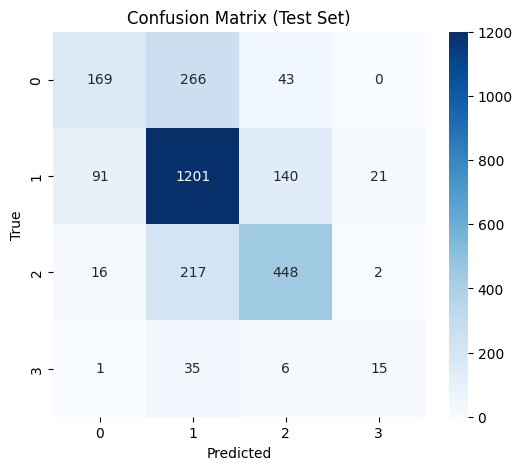

Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 17.64it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │    0.6862598061561584     │
│      test_loss_epoch      │    0.8385880589485168     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.8385880589485168, 'test_acc_epoch': 0.6862598061561584}]

In [167]:
finetuned_lm_w_linear_result = finetuned_lm_w_linear_trainer.test(finetuned_lm_w_linear_model, test_loader)
finetuned_lm_w_linear_result

## Contrastive-based model (SimCSE) with a linear classifier


**SimCSE** (Simple Contrastive Learning of Sentence Embeddings) is a self-supervised learning method that learns high-quality sentence embeddings without relying on any labeled data.  It leverages contrastive learning, a technique where similar examples are encouraged to have similar representations, while dissimilar examples are pushed apart in representation space.

Here's the core idea in a nutshell:

- **Data Augmentation**:  SimCSE starts with a batch of sentences. For each sentence, it creates two slightly different "views" of the same sentence.  These views are created through simple augmentations, like dropout (randomly masking some words) or other minor perturbations.  These augmented sentences are semantically similar to the original.

- **Contrastive Objective**: The core of SimCSE is a contrastive loss function.  It treats the two different views of the same sentence as a positive pair – the model should learn to make their embeddings similar.  All other sentences in the batch (including their augmented versions) are treated as negative pairs – their embeddings should be dissimilar.

- **Learning**: The model is trained to minimize this contrastive loss.  This forces the model to learn sentence embeddings that are robust to the augmentations and capture the underlying semantic meaning of the sentences.  Sentences with similar meanings will have embeddings close together, while sentences with different meanings will have embeddings far apart.

Paper: https://arxiv.org/pdf/2104.08821.pdf


**Unsupervised SimCSE** is the foundation of the SimCSE method. It's a way to learn sentence embeddings without any labeled data.

**Core idea of its concept**

- **Dropout as Augmentation**: The key idea in unsupervised SimCSE is to use dropout (randomly masking some words during training) as a form of minimal data augmentation.

- **Two Views**: When you feed the same sentence through your transformer model twice, with dropout turned on, you get two slightly different representations (embeddings) of that sentence. These are like two "views" of the same sentence.

- **Contrastive Learning**: The two embeddings of the same sentence (the "views") are treated as a positive pair. The model is trained to make these embeddings similar to each other.
The embeddings of different sentences in the batch are treated as negative pairs. The model is trained to make these embeddings dissimilar to each other.


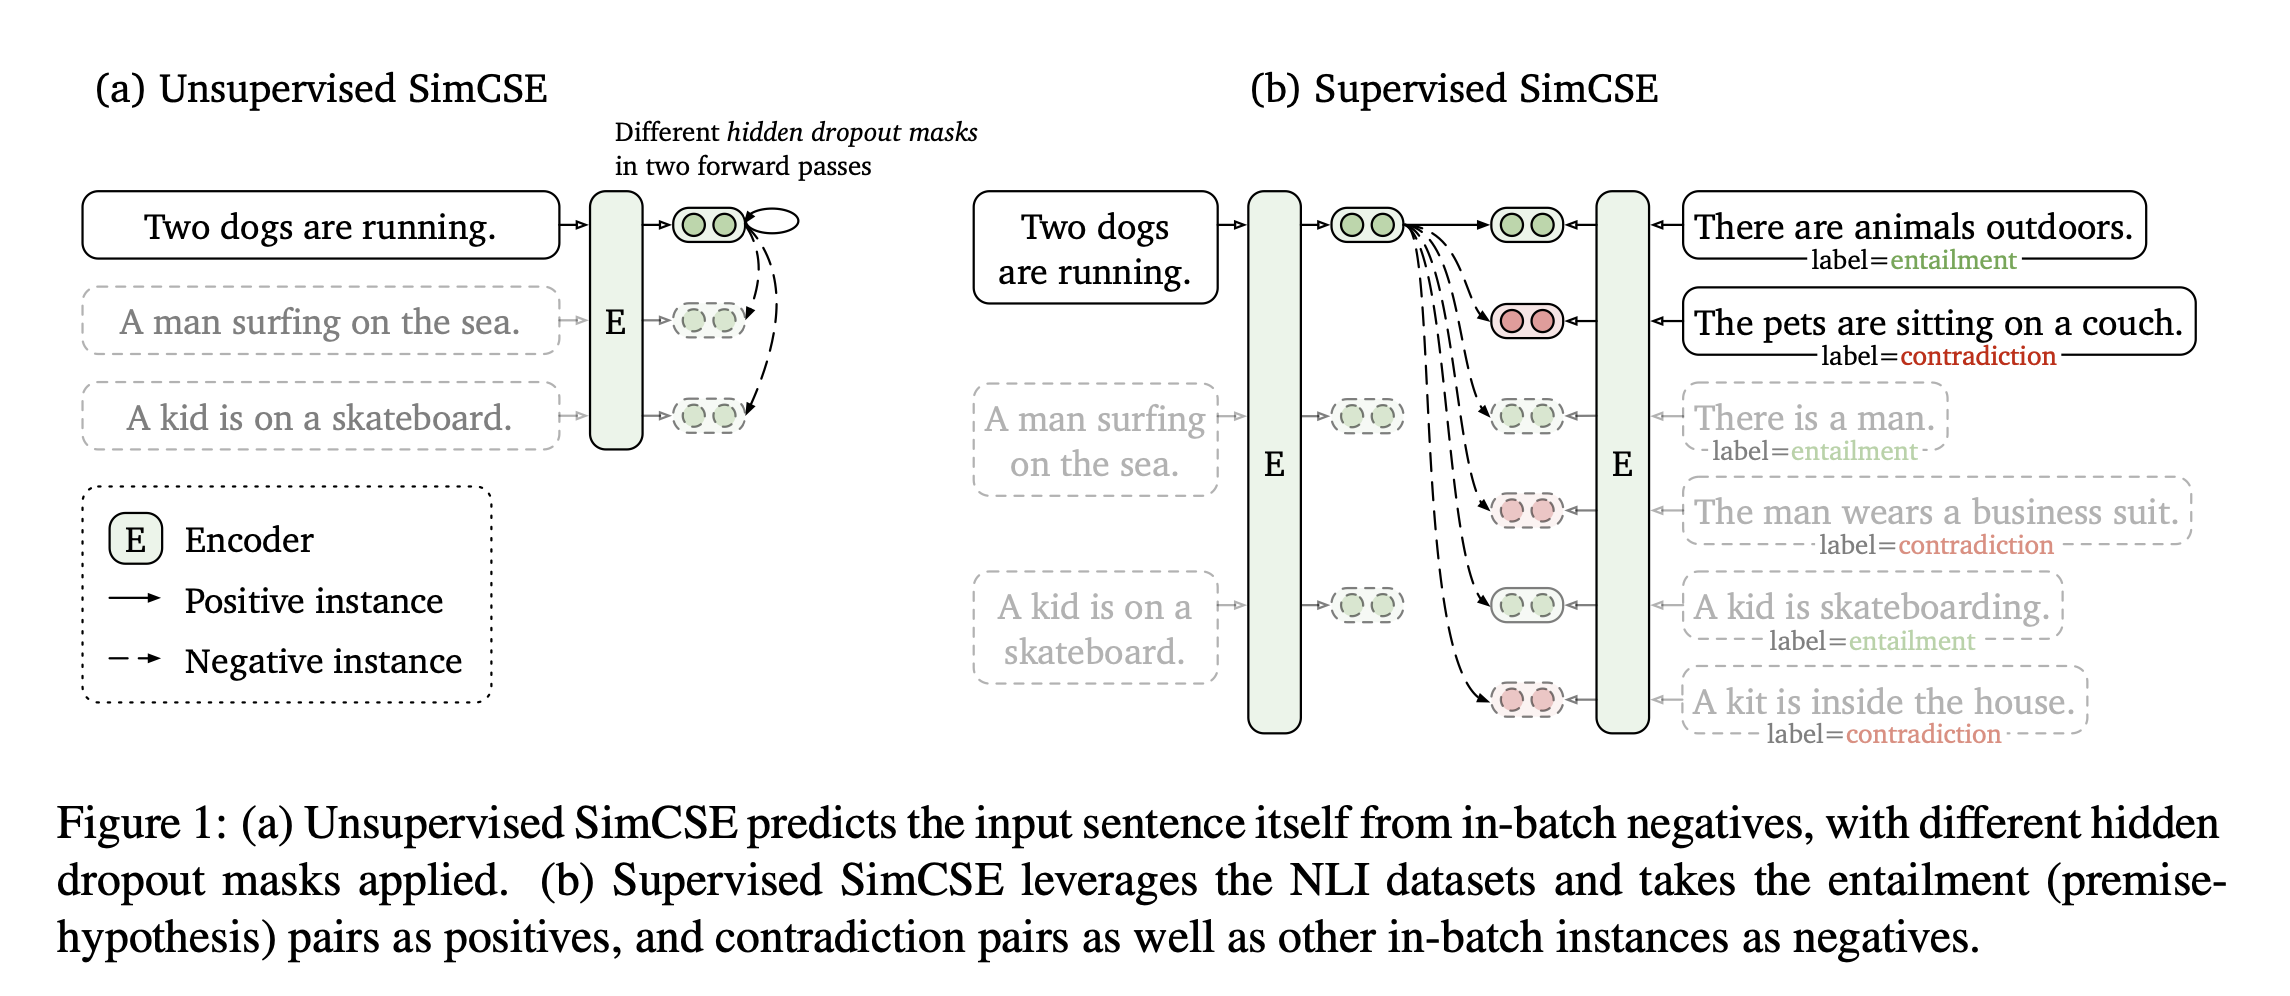

### Defined Unsupervised SimCSE model and InfoNCE loss

$L_{UnsupervisedInfoNCE} = -\log\frac{e^{cos(z_i, z_j) / \tau}}{e^{cos(z_i, z_j) / \tau} + \sum\limits_{k=0}^N{(e^{cos(z_i, z_k) / \tau}})}$

**Notation**

$z_i$ indicates the anchor representation (the representation that we are focusing on). The anchor sentence is the initial sentence which its representation is augmented by the dropout masking layer.

$z_j$ indicates the positive representation (the representation that has the same semantic direction). The positive sentence is the same sentence as the anchor one but the positive representation is augmented in different way by the same dropout masking layer.

$z_k$ indicates the negative representation (the representation that has the opposite semantic direction). The negative sentence are the other sentences sampled besides the anchor/positive sentence.

$cos(\cdot, \cdot)$ is cosine similairity function

$N$ is the number of negative examples

**Hint**

For loss calculation section, I suggest you to use `F.crossentropy` function and the idea of in-batch negative sampling.

**Recommendation:** If VRAM is insufficient, restart the runtime.








In [168]:
class UnsupervisedSimCSE(BaseModel):
    def __init__(
          self,
          model_name: str = 'distilbert-base-multilingual-cased',
          learning_rate: float = 2e-6,
          temperature: float = 0.05,
    ):
        super().__init__(
            model_name,
            learning_rate
        )
        self.save_hyperparameters()
        self.temperature = temperature

        # TODO 8: enable dropout masking in transformer layers to do data augmentation
        # Dropout layers behave differently during training and inference
        # https://discuss.pytorch.org/t/if-my-model-has-dropout-do-i-have-to-alternate-between-model-eval-and-model-train-during-training/83007/2
        self.encoder.train() 
        # to check dropout 
        # print(self.encoder.training)  # should return true if dropout work
        
    def forward(self, input_ids, attention_mask):
        return self.get_embeddings(input_ids, attention_mask)

    # TODO 9.1: implement unsupervised InfoNCE loss
    def training_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']

        # Forward pass 2 รอบ (เนื่องจากเปิด dropout จึงได้ embeddings ที่แตกต่างกัน)
        # First forward pass
        embeddings1 = self(input_ids, attention_mask)     

        # Second forward pass with different dropout
        embeddings2 = self(input_ids, attention_mask)

        # Normalize embeddings เพื่อใช้กับ cosine similarity
        embeddings1 = F.normalize(embeddings1, p=2, dim=1)    # apply L2 norm #####
        embeddings2 = F.normalize(embeddings2, p=2, dim=1)    # apply L2 norm #####

        ## Combine embeddings
        # รวม embeddings ทั้งสองรอบ: [2N, hidden_size]
        embeddings = torch.cat([embeddings1, embeddings2], dim=0) ######

        ## Calculate loss
        # สร้าง similarity matrix: [2N, 2N]
        similarity_matrix = torch.matmul(embeddings, embeddings.T) ######

        # ปิดการ matching กับตัวเอง โดยใช้ masking
        batch_size = input_ids.size(0)
        labels = torch.arange(batch_size, device=self.device)
        labels = torch.cat([labels + batch_size, labels])  # คู่บวกของแต่ละ embedding
        mask = torch.eye(2 * batch_size, device=self.device).bool()
        similarity_matrix.masked_fill_(mask, -1e4)

        # คูณอุณหภูมิ (temperature scaling)
        similarity_matrix = similarity_matrix / self.temperature

        ## Log loss
        # คำนวณ InfoNCE loss ด้วย cross entropy
        loss = F.cross_entropy(similarity_matrix, labels) ###### 

        self.log("train_loss",loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss


    # TODO 9.2: implement the same as `training_step`
    def validation_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']

        # Forward pass 2 รอบ (เนื่องจากเปิด dropout จึงได้ embeddings ที่แตกต่างกัน)
        # First forward pass
        embeddings1 = self(input_ids, attention_mask)     

        # Second forward pass with different dropout
        embeddings2 = self(input_ids, attention_mask)

        # Normalize embeddings เพื่อใช้กับ cosine similarity
        embeddings1 = F.normalize(embeddings1, p=2, dim=1)    # apply L2 norm #####
        embeddings2 = F.normalize(embeddings2, p=2, dim=1)    # apply L2 norm #####

        ## Combine embeddings
        # รวม embeddings ทั้งสองรอบ: [2N, hidden_size]
        embeddings = torch.cat([embeddings1, embeddings2], dim=0) ######

        ## Calculate loss
        # สร้าง similarity matrix: [2N, 2N]
        similarity_matrix = torch.matmul(embeddings, embeddings.T) ######

        # ปิดการ matching กับตัวเอง โดยใช้ masking
        batch_size = input_ids.size(0)
        labels = torch.arange(batch_size, device=self.device)
        labels = torch.cat([labels + batch_size, labels])  # คู่บวกของแต่ละ embedding
        mask = torch.eye(2 * batch_size, device=self.device).bool()
        similarity_matrix.masked_fill_(mask, -1e4)

        # คูณอุณหภูมิ (temperature scaling)
        similarity_matrix = similarity_matrix / self.temperature

        ## Log loss
        # คำนวณ InfoNCE loss ด้วย cross entropy
        loss = F.cross_entropy(similarity_matrix, labels) ###### 
        
        self.log("val_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    # TODO 9.3: implement the same as `training_step`
    def test_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']

        # Forward pass 2 รอบ (เนื่องจากเปิด dropout จึงได้ embeddings ที่แตกต่างกัน)
        # First forward pass
        embeddings1 = self(input_ids, attention_mask)     

        # Second forward pass with different dropout
        embeddings2 = self(input_ids, attention_mask)

        # Normalize embeddings เพื่อใช้กับ cosine similarity
        embeddings1 = F.normalize(embeddings1, p=2, dim=1)    # apply L2 norm #####
        embeddings2 = F.normalize(embeddings2, p=2, dim=1)    # apply L2 norm #####

        ## Combine embeddings
        # รวม embeddings ทั้งสองรอบ: [2N, hidden_size]
        embeddings = torch.cat([embeddings1, embeddings2], dim=0) ######

        ## Calculate loss
        # สร้าง similarity matrix: [2N, 2N]
        similarity_matrix = torch.matmul(embeddings, embeddings.T) ######

        # ปิดการ matching กับตัวเอง โดยใช้ masking
        batch_size = input_ids.size(0)
        labels = torch.arange(batch_size, device=self.device)
        labels = torch.cat([labels + batch_size, labels])  # คู่บวกของแต่ละ embedding
        mask = torch.eye(2 * batch_size, device=self.device).bool()
        similarity_matrix.masked_fill_(mask, -1e4)

        # คูณอุณหภูมิ (temperature scaling)
        similarity_matrix = similarity_matrix / self.temperature

        ## Log loss
        # คำนวณ InfoNCE loss ด้วย cross entropy
        loss = F.cross_entropy(similarity_matrix, labels) ###### 
        
        self.log("test_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss


### Train LM through SimCSE approach

In [170]:
# Initialize model
model = UnsupervisedSimCSE()


simcse_checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_loss",
    mode="min",  # because lower loss is better
    save_top_k=1,
    save_weights_only=True,
    dirpath="./checkpoints/",
    filename="simcse-{epoch}-{train_loss:.2f}",
    verbose=True
)


logger = TensorBoardLogger("lightning_logs", name="simcse")

# Initialize trainer
simcse_trainer = Trainer(
    logger=logger,
    max_epochs=3,
    accelerator='auto',
    callbacks=[simcse_checkpoint_callback],
    devices=1,
    gradient_clip_val=1.0,
    precision=16  # Mixed precision training
)

# Train the model
simcse_trainer.fit(model, train_loader, val_loader)

# Save the latest checkpoint
# simcse_trainer.save_checkpoint('/checkpoints/latest_simcse_checkpoint.ckpt')

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\lightning_fabric\connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\Aitthikit\Desktop\NLP\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type            | Params | Mode 
----------------------------------------------------
0 | encoder | DistilBertModel | 134 M  | train
----------------------------------------------------
134 M     Trainable params
0         Non-trainable params
134 M     Total params
538.936   Total estimated model params size (MB)
92        Modules in train mode
0         Modules in e

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 676/676 [04:05<00:00,  2.75it/s, v_num=1, train_loss_step=0.000876, val_loss_step=2.09e-7, val_loss_epoch=0.014, train_loss_epoch=0.173]

...

Epoch 1: 100%|██████████| 676/676 [04:07<00:00,  2.73it/s, v_num=1, train_loss_step=0.167, val_loss_step=1.19e-7, val_loss_epoch=0.0139, train_loss_epoch=0.00996]

Epoch 1, global step 1352: 'val_loss' reached 0.01388 (best 0.01388), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\simcse-epoch=1-train_loss=0.01.ckpt' as top 1


Epoch 2: 100%|██████████| 676/676 [04:07<00:00,  2.73it/s, v_num=1, train_loss_step=0.000156, val_loss_step=1.79e-7, val_loss_epoch=0.0138, train_loss_epoch=0.0101] 

Epoch 2, global step 2028: 'val_loss' reached 0.01382 (best 0.01382), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\simcse-epoch=2-train_loss=0.01.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 676/676 [04:08<00:00,  2.72it/s, v_num=1, train_loss_step=0.000156, val_loss_step=1.79e-7, val_loss_epoch=0.0138, train_loss_epoch=0.0101]


In [171]:
simcse_result = simcse_trainer.test(model, test_loader)
simcse_result

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 84/84 [00:07<00:00, 10.51it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_loss_epoch      │   0.011196921579539776    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.011196921579539776}]

### Define SimCSE with a linear classifier model

After training SimCSE on the data, we proceed to train a linear classifier on top of the trained model. Be sure to freeze the encoder weights.


In [173]:
latest_simcse_ckpt_path = 'checkpoints/simcse-epoch=2-train_loss=0.01.ckpt'

simcse_lm_w_linear_model_wo = LMWithLinearClassfier(
    model_name,
    ckpt_path=latest_simcse_ckpt_path,
    freeze_encoder_weights=True
)

C:\Users\Aitthikit\AppData\Local\Temp\ipykernel_10288\3010160820.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location='cpu')


### Train a linear classifier

In [175]:
# Create a ModelCheckpoint callback (recommended way):
simcse_lm_w_linear_checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_acc",  # Metric to monitor
    mode="max",  # "min" for loss, "max" for accuracy
    save_top_k=1,  # Save only the best model(s)
    save_weights_only=True, # Saves only weights, not the entire model
    dirpath="./checkpoints/", # Path where the checkpoints will be saved
    filename="best_simcse_linear_model-{epoch}-{val_acc:.2f}", # Customized name for the checkpoint
    verbose=True,
)

logger = TensorBoardLogger("lightning_logs", name="simcse_LM")

# Initialize trainer
simcse_lm_w_linear_trainer_wo = Trainer(
    logger=logger,
    max_epochs=3,
    accelerator='auto',
    callbacks=[simcse_lm_w_linear_checkpoint_callback], # Add the ModelCheckpoint callback
    gradient_clip_val=1.0,
    precision=16, # Mixed precision training
    devices=1,
)

# Train the model
simcse_lm_w_linear_trainer_wo.fit(simcse_lm_w_linear_model_wo, train_loader, val_loader)

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\lightning_fabric\connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\Aitthikit\Desktop\NLP\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | encoder    | DistilBertModel    | 134 M  | eval 
1 | classifier | Linear             | 3.1 K  | train
2 | accuracy   | MulticlassAccuracy | 0      | train
----------------------------------------------------------
3.1 K     Trainable params
134 M     Non-trainable par

Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 69.16it/s]

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 676/676 [00:40<00:00, 16.87it/s, v_num=3, train_loss_step=1.300, train_acc_step=0.571, val_loss_step=1.210, val_acc_step=0.750, val_loss_epoch=1.290, val_acc_epoch=0.493, train_loss_epoch=1.350, train_acc_epoch=0.364]

...

Epoch 1: 100%|██████████| 676/676 [00:39<00:00, 16.98it/s, v_num=3, train_loss_step=1.280, train_acc_step=0.393, val_loss_step=1.040, val_acc_step=1.000, val_loss_epoch=1.190, val_acc_epoch=0.566, train_loss_epoch=1.240, train_acc_epoch=0.536]

Epoch 1, global step 1352: 'val_acc' reached 0.56572 (best 0.56572), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\best_simcse_linear_model-epoch=1-val_acc=0.57.ckpt' as top 1


Epoch 2: 100%|██████████| 676/676 [00:39<00:00, 16.95it/s, v_num=3, train_loss_step=1.140, train_acc_step=0.571, val_loss_step=0.926, val_acc_step=1.000, val_loss_epoch=1.120, val_acc_epoch=0.576, train_loss_epoch=1.160, train_acc_epoch=0.572]

Epoch 2, global step 2028: 'val_acc' reached 0.57571 (best 0.57571), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\best_simcse_linear_model-epoch=2-val_acc=0.58.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 676/676 [00:40<00:00, 16.53it/s, v_num=3, train_loss_step=1.140, train_acc_step=0.571, val_loss_step=0.926, val_acc_step=1.000, val_loss_epoch=1.120, val_acc_epoch=0.576, train_loss_epoch=1.160, train_acc_epoch=0.572]


### Evaluate

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 18.49it/s]

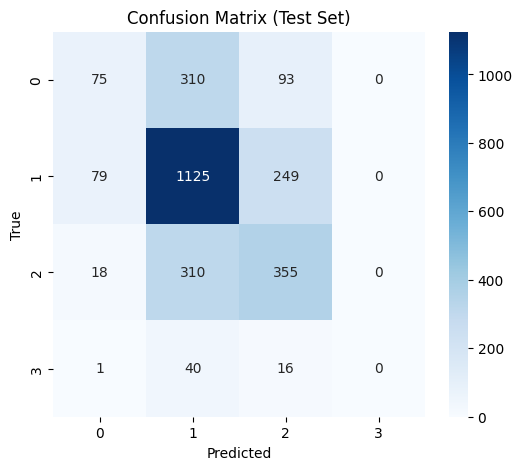

Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 18.25it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │    0.5821789503097534     │
│      test_loss_epoch      │    1.1207525730133057     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 1.1207525730133057, 'test_acc_epoch': 0.5821789503097534}]

In [176]:
simcse_lm_w_linear_result_wo = simcse_lm_w_linear_trainer_wo.test(simcse_lm_w_linear_model_wo, test_loader)
simcse_lm_w_linear_result_wo

### Fine-tuned LM simcse

In [177]:
#TODO 10: Try Fine-tuned LM simcse

latest_simcse_ckpt_path = 'checkpoints/simcse-epoch=2-train_loss=0.01.ckpt'

simcse_lm_w_linear_model = LMWithLinearClassfier(
model_name,
ckpt_path=latest_simcse_ckpt_path,
freeze_encoder_weights=False
)

C:\Users\Aitthikit\AppData\Local\Temp\ipykernel_10288\3010160820.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location='cpu')


In [178]:
# Create a ModelCheckpoint callback (recommended way):
simcse_lm_w_linear_checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_acc",  # Metric to monitor
    mode="max",  # "min" for loss, "max" for accuracy
    save_top_k=1,  # Save only the best model(s)
    save_weights_only=True, # Saves only weights, not the entire model
    dirpath="./checkpoints/", # Path where the checkpoints will be saved
    filename="best_finetuned_simcse_linear_model-{epoch}-{val_acc:.2f}", # Customized name for the checkpoint
    verbose=True,
)

logger = TensorBoardLogger("lightning_logs", name="fine_tune_simcse_LM")

# Initialize trainer
simcse_lm_w_linear_trainer = Trainer(
    logger=logger,
    max_epochs=3,
    accelerator='auto',
    callbacks=[simcse_lm_w_linear_checkpoint_callback], # Add the ModelCheckpoint callback
    gradient_clip_val=1.0,
    precision=16, # Mixed precision training
    devices=1,
)

8# Train the model
simcse_lm_w_linear_trainer.fit(simcse_lm_w_linear_model, train_loader, val_loader)

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\lightning_fabric\connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\Aitthikit\Desktop\NLP\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode 
----------------------------------------------------------
0 | encoder    | DistilBertModel    | 134 M  | eval 
1 | classifier | Linear             | 3.1 K  | train
2 | accuracy   | MulticlassAccuracy | 0      | train
----------------------------------------------------------
134 M     Trainable params
0         Non-trainable par

Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 95.31it/s]

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 676/676 [01:56<00:00,  5.80it/s, v_num=0, train_loss_step=0.494, train_acc_step=0.786, val_loss_step=0.322, val_acc_step=1.000, val_loss_epoch=0.775, val_acc_epoch=0.679, train_loss_epoch=0.848, train_acc_epoch=0.647]

...

Epoch 1: 100%|██████████| 676/676 [01:58<00:00,  5.69it/s, v_num=0, train_loss_step=0.509, train_acc_step=0.786, val_loss_step=0.265, val_acc_step=1.000, val_loss_epoch=0.715, val_acc_epoch=0.706, train_loss_epoch=0.658, train_acc_epoch=0.732]

Epoch 1, global step 1352: 'val_acc' reached 0.70632 (best 0.70632), saving model to 'C:\\Users\\Aitthikit\\Desktop\\NLP\\checkpoints\\best_finetuned_simcse_linear_model-epoch=1-val_acc=0.71.ckpt' as top 1


Epoch 2: 100%|██████████| 676/676 [01:57<00:00,  5.74it/s, v_num=0, train_loss_step=0.483, train_acc_step=0.821, val_loss_step=0.195, val_acc_step=1.000, val_loss_epoch=0.818, val_acc_epoch=0.704, train_loss_epoch=0.461, train_acc_epoch=0.816]

Epoch 2, global step 2028: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 676/676 [01:57<00:00,  5.74it/s, v_num=0, train_loss_step=0.483, train_acc_step=0.821, val_loss_step=0.195, val_acc_step=1.000, val_loss_epoch=0.818, val_acc_epoch=0.704, train_loss_epoch=0.461, train_acc_epoch=0.816]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 18.77it/s]

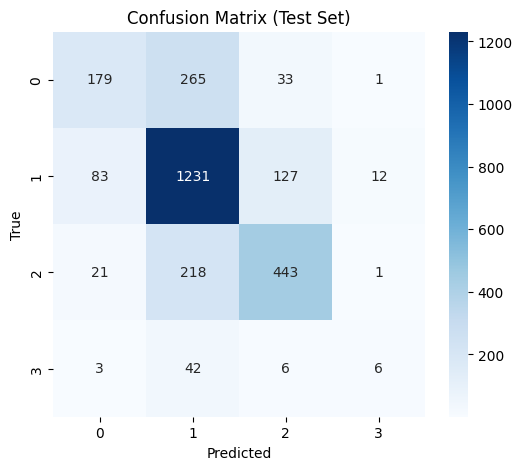

Testing DataLoader 0: 100%|██████████| 84/84 [00:04<00:00, 18.51it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │    0.6959940195083618     │
│      test_loss_epoch      │    0.8078712224960327     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.8078712224960327, 'test_acc_epoch': 0.6959940195083618}]

In [179]:
simcse_lm_w_linear_result = simcse_lm_w_linear_trainer.test(simcse_lm_w_linear_model, test_loader)
simcse_lm_w_linear_result

## **Summary (Compare performance for all models & the best model)**   
TODO 11: Compare performance (test_acc and test_loss) of all (4) models



In [ ]:
# Define function to collect evaluation matric(confusion matrix, precision, recall, f1)
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def plot_cf(model, dataloader, ax, title="Confusion Matrix"):
    model.eval()
    model.to(device)
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            
            if isinstance(outputs, torch.Tensor):
                logits = outputs
            else:
                logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')  
    recall = recall_score(all_labels, all_preds, average='weighted')  
    f1 = f1_score(all_labels, all_preds, average='weighted')  

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{title}\nAccuracy: {accuracy:.2f}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    return cm, accuracy, precision, recall, f1

In [ ]:
# Result from testing dataset (Accuracy, loss)
print("\t"*5, "Test accuracy", "\t"*2, "Test loss")
print("Linear model (pretrain weight): ", "\t", round(pretrained_lm_w_linear_result[0]['test_acc_epoch'], 2), "\t"*3, round(pretrained_lm_w_linear_result[0]['test_loss_epoch'],2))
print("Linear model (finetuned weight):", "\t", round(finetuned_lm_w_linear_result[0]['test_acc_epoch'],2), "\t"*3, round(finetuned_lm_w_linear_result[0]['test_loss_epoch'],2))
print("simCSE with Linear (pretrain weight)","\t", round(simcse_lm_w_linear_result_wo[0]['test_acc_epoch'], 2), "\t"*3,round(simcse_lm_w_linear_result_wo[0]['test_loss_epoch'], 2))
print("simCSE with Linear (finetuned weight)","\t",  round(simcse_lm_w_linear_result[0]['test_acc_epoch'],2), "\t"*3,round(simcse_lm_w_linear_result[0]['test_loss_epoch'],2))

					 Test accuracy 		 Test loss
Linear model (pretrain weight):  	 0.54 			 1.03
Linear model (finetuned weight): 	 0.69 			 0.84
simCSE with Linear (pretrain weight) 	 0.58 			 1.12
simCSE with Linear (finetuned weight) 	 0.7 			 0.81


In the testing result, both linear model and simCSE+linear model with pretrain weight have closly accuracy(0.54, 0.58) and also in loss(1.03, 1.12). In both of fine tune linear model and simCSE+linear has closly accuracy(0.69, 0.70) and loss(0.84, 0.81) but both are higher than the pretrain weight. We can see fine-tuned model effect to increasing accuracy both supervised and self-supervised.

### **Confusion Matrix**

c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Aitthikit\Desktop\NLP\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


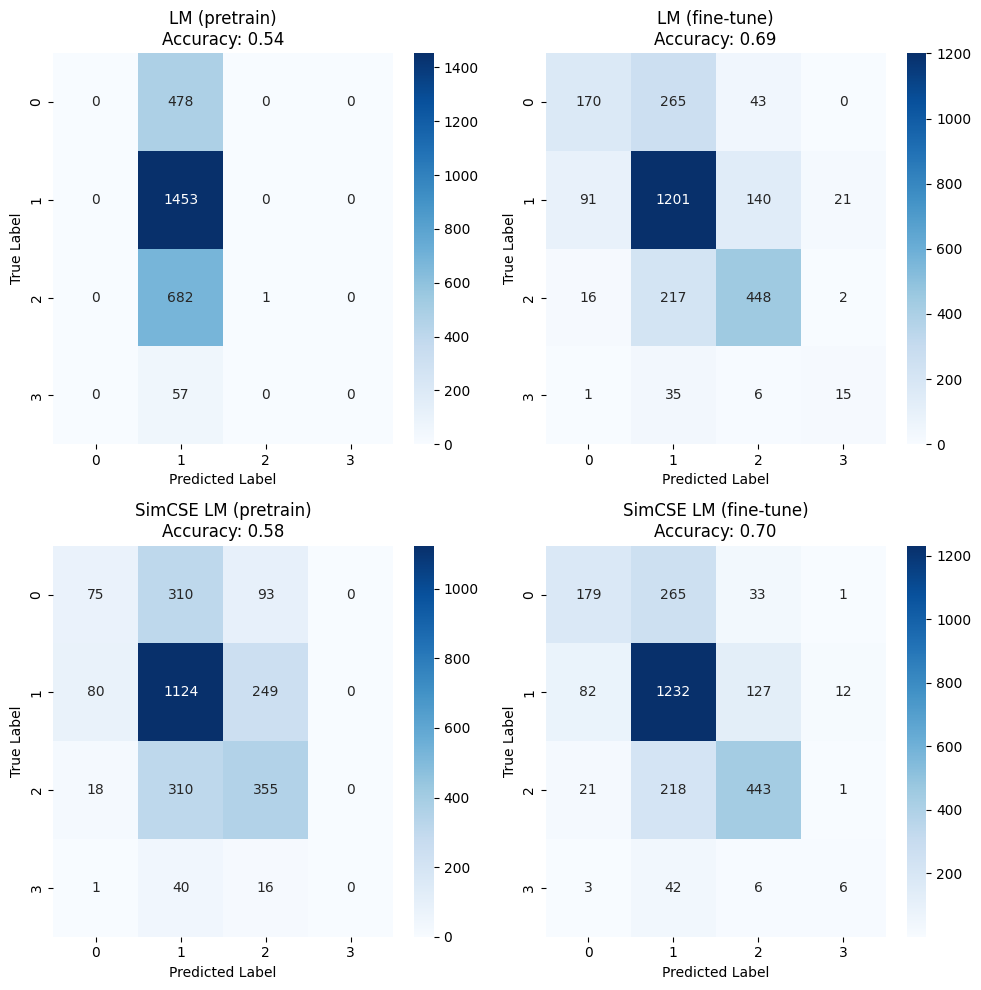

In [ ]:
# Plot confusion matrix for all models
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

models = [
    pretrained_lm_w_linear_model,
    finetuned_lm_w_linear_model,
    simcse_lm_w_linear_model_wo,
    simcse_lm_w_linear_model
]

dataloaders = [test_loader, test_loader, test_loader, test_loader] 
titles = ['LM (pretrain)', 'LM (fine-tune)', 'SimCSE LM (pretrain)', 'SimCSE LM (fine-tune)']
metrics = []
for ax, model, dataloader, title in zip(axs.flat, models, dataloaders, titles):
    cm, accuracy, precision, recall, f1 = plot_cf(model, dataloader, ax, title)
    metrics.append((title, accuracy, precision, recall, f1))

plt.tight_layout()
plt.show()

Linear model
- (pretrain): Mostly predict on `class 1`, model doesn't predict on the other classes
- (fine-tuned): Model provide more distribution predict than pretrain.

simCSE + linear mode
- (pretrain): Model provide distribution predict but without predict `class 3`.
- (fine-tuned):  Model provide more distribution predict than pretrain.

In [227]:
print("Evaluation metrics for Testing dataset\n")

# Header row
print(f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 70)

# Data rows
for i in metrics:
    title, acc, prec, rec, f1 = i
    print(f"{title:<25} {acc:<10.2f} {prec:<10.2f} {rec:<10.2f} {f1:<10.2f}")


Evaluation metrics for Testing dataset

Model                     Accuracy   Precision  Recall     F1-Score  
----------------------------------------------------------------------
LM (pretrain)             0.54       0.55       0.54       0.38      
LM (fine-tune)            0.69       0.68       0.69       0.67      
SimCSE LM (pretrain)      0.58       0.55       0.58       0.55      
SimCSE LM (fine-tune)     0.70       0.69       0.70       0.68      


1. Finetuning vs Frozen weight
    - Finetuning the encoder weight significantly improve performance for both approaches
2. F1 score 
    - Finetuning improve F1 score from pretrain linear model(0.38) to finetuning linear model(0.67)
    - F1 score indicate performance across all classes, not just for the majority class.

**The best model** is `SimCSE + linear model` with finetuning has the highest evaluate metric for accuracy, precision, recall, F1.   
- Why SimCSE is the best performance
    - SimCSE create embedding that better capture semantic similarities through contrastive learning.
    - Self supervised nature allow the model to learn meaningfull representations without relying solely on the labeled data

## **Graph** 

### **Train for 3 Epochs**   
1 epoch : 676 steps   
- LM with pretrain (Gray)
- LM with findtuning (Light blue)
- SimCSE+LM with pretrain (Yellow)
- SimCSE+LM with findtuning (Purple)

#### Training set

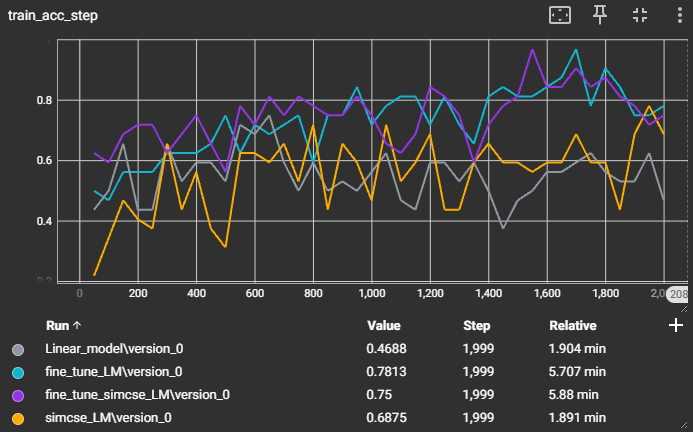

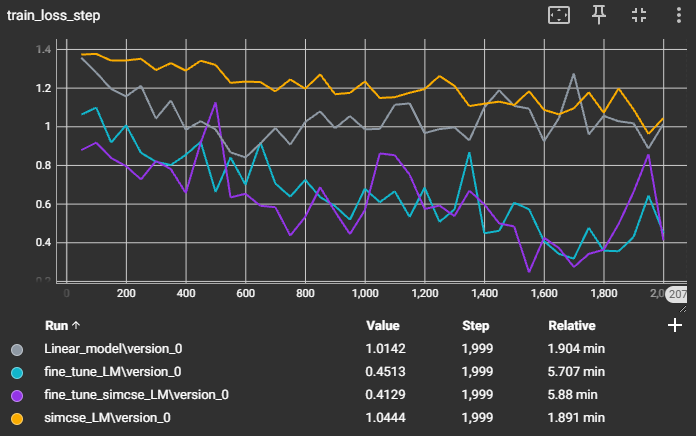

In [10]:
from IPython.display import display, Image

display(Image("image/train_acc.png", width= 800))
display(Image("image/train_loss.png", width= 800))

In training accuracy and loss we can split in to 2 groups, firstly with pretrain that has lower accuracy and higher loss(lower rate of change for loss), secondly with findtuning that has higher accuracy and lower loss(model learn due adjusting weight)

#### Validation set

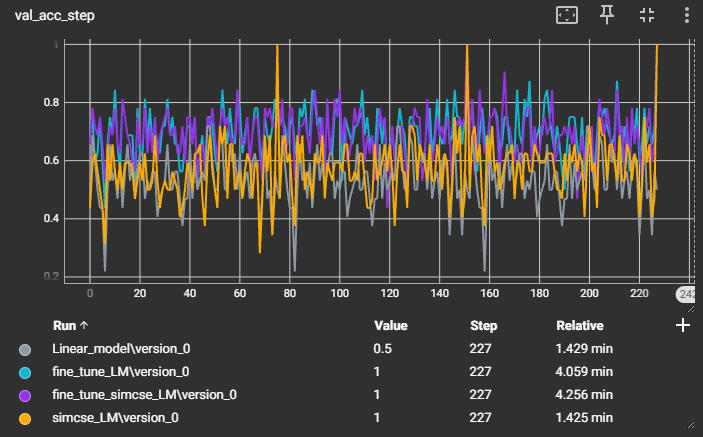

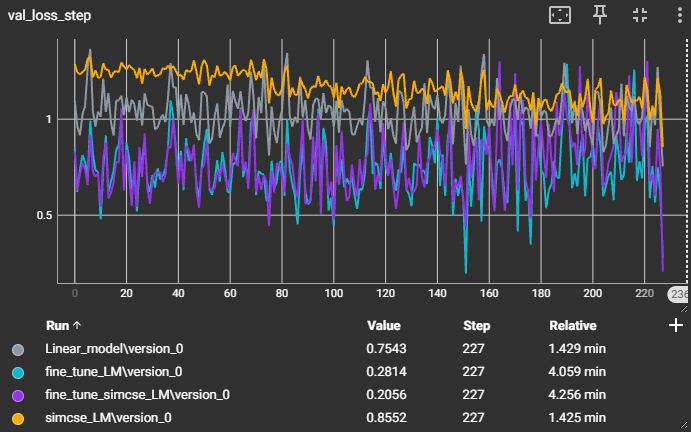

In [11]:
display(Image("image/val_acc.png", width= 800))
display(Image("image/val_loss.png", width= 800))

In validate we can split into 2 groups like above that are pretrain and findtuning, that group of findtuning has higher accuracy. In the validate loss we can pretrain weight higher than findtuning but in lastly step of findtuning has some osilate may prone to be over fitting if we train more epochs.

#### Testing set

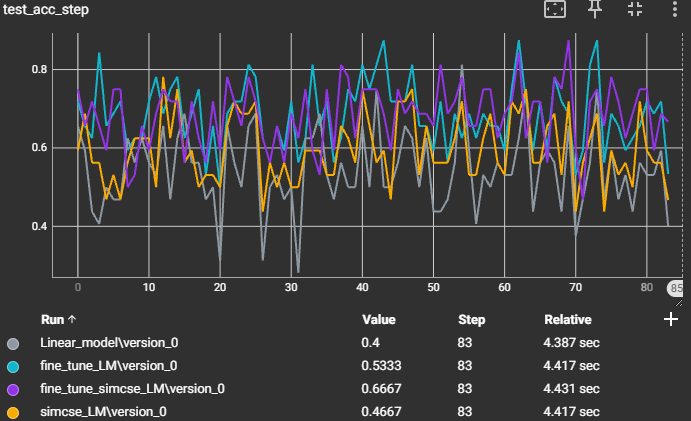

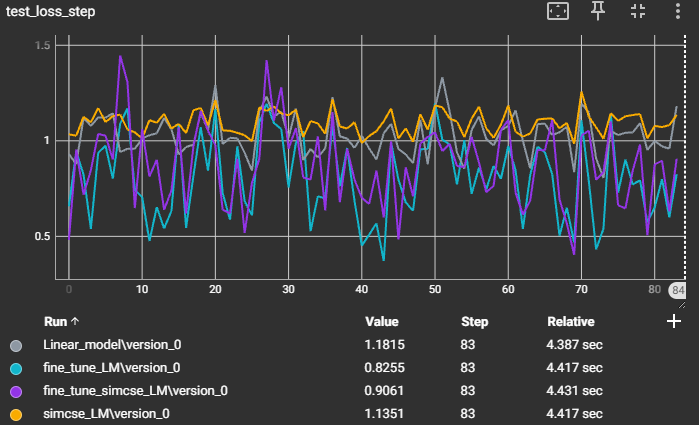

In [13]:
display(Image("image/test_acc.png", width= 800))
display(Image("image/test_loss.png", width= 800))

In the test set findtuning has higher accuracy, in loss with pretrain has consistence loss around 1 but findtuning mostly step has lower loss but some step has more than the pretrain.

### **Train for 10 Epochs (For testing more train)**   
1 epoch : 676 steps   
- LM with pretrain (Gray)
- LM with findtuning (Light blue)
- SimCSE+LM with pretrain (Yellow)
- SimCSE+LM with findtuning (Purple)

- SimCSE loss (Pink)

#### Training set

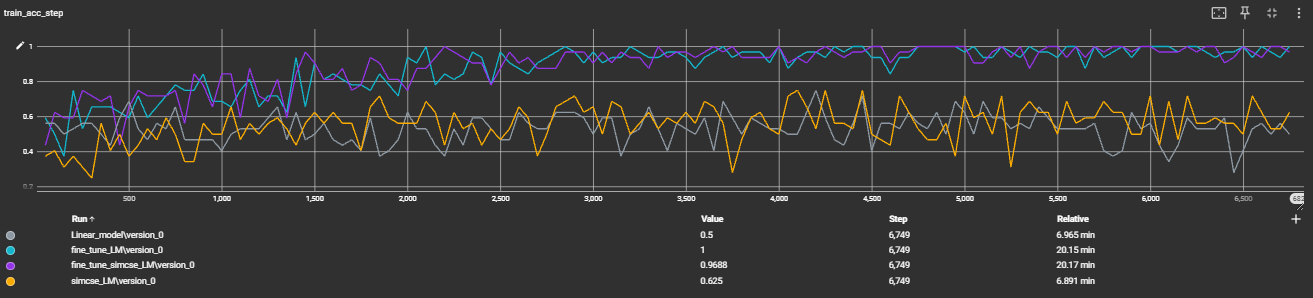

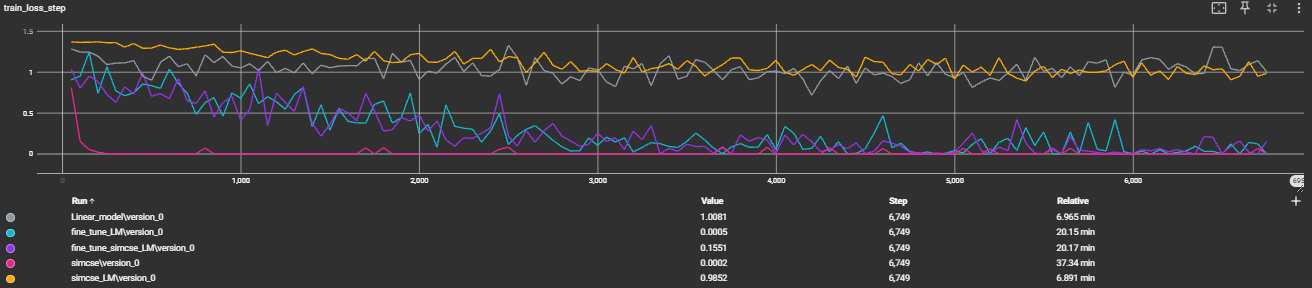

In [15]:
display(Image("image/10_train_acc.png", width= 1500))
display(Image("image/10_train_loss.png", width= 1500))

After we increasing the training epoch the accuracy of findtuning in lastly steps has closly to 1 and loss of fintuning has closly to 0

#### Validation set

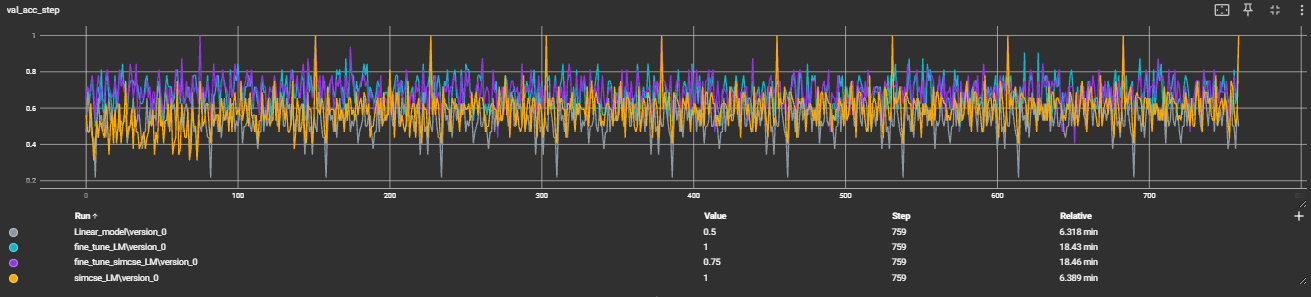

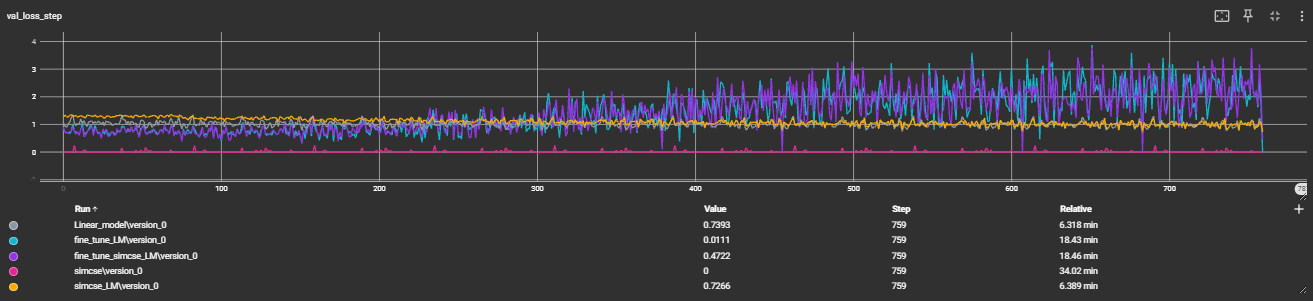

In [16]:
display(Image("image/10_val_acc.png", width= 1500))
display(Image("image/10_val_loss.png", width= 1500))

In validation set we can see the accuracy of findtuning around 0.6-0.7 but the loss of findtuning has increasing and more osilate after passing step 2000, that mean the model trying to learn too much for training set or overfitting problem.

#### Testing set

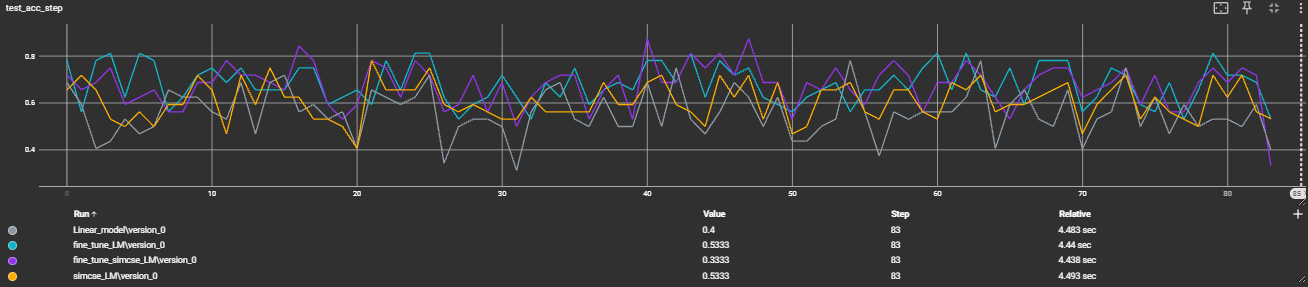

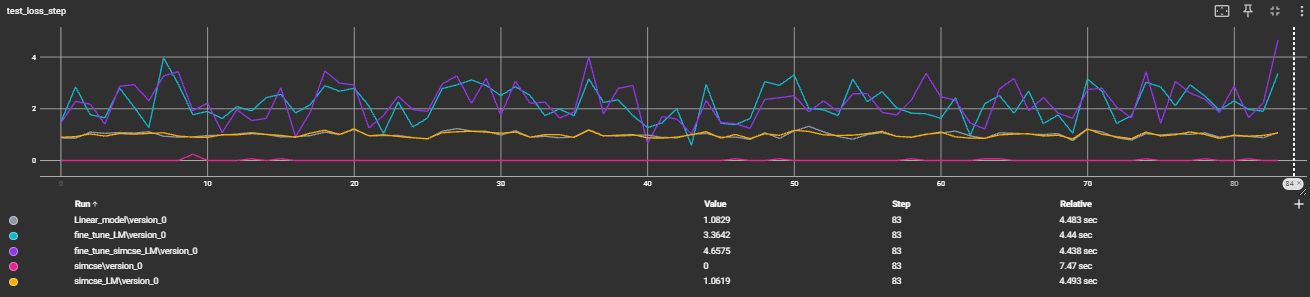

In [17]:
display(Image("image/10_test_acc.png", width= 1500))
display(Image("image/10_test_loss.png", width= 1500))

Testing set of 10 epochs training with findtuning has higher loss than pretrain.

Summarize for this situation

    Overfitting to fine tune data: The model memorized the small fine tuning dataset and loss the generalization, that we can do method like early stop, lower learning rate, add regularize or etc. for protect this overfitting situation.